In [1]:
# STEP 1: Import Required Libraries
# These libraries create the environment for systematic data evaluation
# ------------------------------

import pandas as pd          # Used for data manipulation and analysis
import numpy as np           # Used for numerical operations
import matplotlib.pyplot as plt   # Used for plotting graphs
import seaborn as sns        # Used for advanced data visualization


# STEP 2: Load the Dataset
# Load the student performance dataset into the analysis environment
#---------------------------------

df = pd.read_csv("StudentPerformanceFactors.csv")

# Display first 5 rows to verify that the dataset is loaded correctly
print("First 5 Rows of Dataset:")
print(df.head())



# STEP 3: Evaluate Dataset Structure
# Check dataset size, columns, and data types
#---------------------------------

print("\nDataset Shape (Rows, Columns):")
print(df.shape)

print("\nColumn Names:")
print(df.columns)

print("\nDataset Information:")
print(df.info())


# STEP 4: Check for Missing Values
# Ensures data quality before performing analysis
#-----------------------------------

print("\nMissing Values in Each Column:")
print(df.isnull().sum())

# If missing values exist, remove them
df = df.dropna()

First 5 Rows of Dataset:
   Id  Hours_Studied  Attendance Parental_Involvement Access_to_Resources  \
0   1             23          84                  Low                High   
1   2             19          64                  Low              Medium   
2   3             24          98               Medium              Medium   
3   4             29          89                  Low              Medium   
4   5             19          92               Medium              Medium   

  Extracurricular_Activities  Sleep_Hours  Previous_Scores Motivation_Level  \
0                         No            7               73              Low   
1                         No            8               59              Low   
2                        Yes            7               91           Medium   
3                        Yes            8               98           Medium   
4                        Yes            6               65           Medium   

  Internet_Access  Tutoring_Sessions 

In [3]:
# ------------------------------
# 6: Exploratory Data Analysis (EDA)
# ------------------------------

# Correlation between numerical columns
correlation_matrix = df.corr(numeric_only=True)

# Display correlation
print(correlation_matrix)

# Create new feature (Performance Category) based on Exam_Score
df["Performance_Level"] = pd.cut(
    df["Exam_Score"],
    bins=[0, 40, 60, 80, 100],
    labels=["Poor", "Average", "Good", "Excellent"]
)

# View updated dataset
df.head().T

                         Id  Hours_Studied  Attendance  Sleep_Hours  \
Id                 1.000000      -0.032458    0.008814     0.008528   
Hours_Studied     -0.032458       1.000000   -0.005249     0.014114   
Attendance         0.008814      -0.005249    1.000000    -0.018384   
Sleep_Hours        0.008528       0.014114   -0.018384     1.000000   
Previous_Scores   -0.001089       0.023286   -0.016834    -0.022340   
Tutoring_Sessions -0.004646      -0.010631    0.013877    -0.011999   
Physical_Activity -0.025642       0.002676   -0.026813    -0.003475   
Exam_Score         0.000801       0.419952    0.551545    -0.013933   

                   Previous_Scores  Tutoring_Sessions  Physical_Activity  \
Id                       -0.001089          -0.004646          -0.025642   
Hours_Studied             0.023286          -0.010631           0.002676   
Attendance               -0.016834           0.013877          -0.026813   
Sleep_Hours              -0.022340          -0.011999   

,0,1,2,3,4
Id,1,2,3,4,5
Hours_Studied,23,19,24,29,19
Attendance,84,64,98,89,92
Parental_Involvement,Low,Low,Medium,Low,Medium
Access_to_Resources,High,Medium,Medium,Medium,Medium
Extracurricular_Activities,No,No,Yes,Yes,Yes
Sleep_Hours,7,8,7,8,6
Previous_Scores,73,59,91,98,65
Motivation_Level,Low,Low,Medium,Medium,Medium
Internet_Access,Yes,Yes,Yes,Yes,Yes


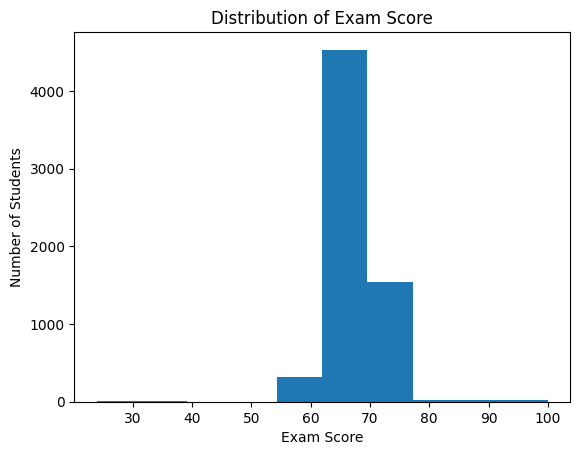

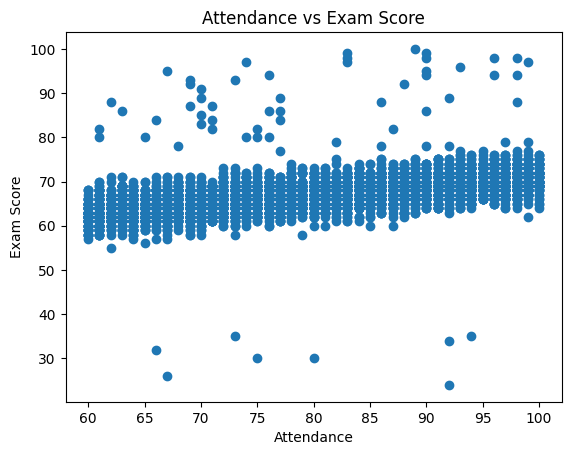

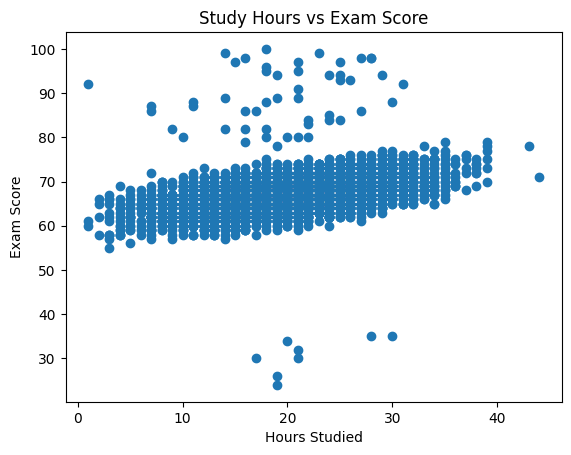

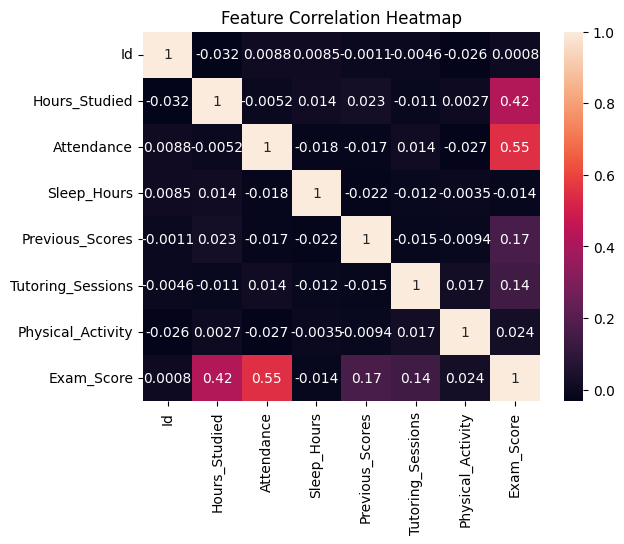

In [4]:
# 7: Data Visualization
# ------------------------------

import seaborn as sns

# 1. Histogram (Exam Score Distribution)
plt.hist(df["Exam_Score"])

plt.title("Distribution of Exam Score")
plt.xlabel("Exam Score")
plt.ylabel("Number of Students")

plt.show()


# 2. Attendance vs Exam Score (Scatter Plot)
plt.scatter(df["Attendance"], df["Exam_Score"])

plt.title("Attendance vs Exam Score")
plt.xlabel("Attendance")
plt.ylabel("Exam Score")

plt.show()


# 3. Study Hours vs Exam Score
plt.scatter(df["Hours_Studied"], df["Exam_Score"])

plt.title("Study Hours vs Exam Score")
plt.xlabel("Hours Studied")
plt.ylabel("Exam Score")

plt.show()


# 4. Heatmap (Correlation)
correlation_matrix = df.corr(numeric_only=True)

sns.heatmap(correlation_matrix, annot=True)

plt.title("Feature Correlation Heatmap")

plt.show()

In [5]:
# 8: Insight Generation
# ------------------------------

# 1. Top performing students
top_students = df.sort_values(by="Exam_Score", ascending=False)

print("Top Students:")
print(top_students.head())


# 2. Average score
average_score = df["Exam_Score"].mean()

print("\nAverage Exam Score:")
print(average_score)


# 3. Create Result Column (Pass/Fail)
# (Example: Pass if score >= 50)

df["Result"] = df["Exam_Score"].apply(lambda x: "Pass" if x >= 50 else "Fail")


# 4. Result count
result_count = df["Result"].value_counts()

print("\nResult Distribution:")
print(result_count)

Top Students:
        Id  Hours_Studied  Attendance Parental_Involvement  \
94      95             18          89                 High   
3579  3580             14          90                 High   
2425  2426             23          83                 High   
1525  1526             27          98                  Low   
6347  6348             28          96                 High   

     Access_to_Resources Extracurricular_Activities  Sleep_Hours  \
94                Medium                        Yes            4   
3579                High                        Yes            8   
2425                High                        Yes            4   
1525              Medium                        Yes            6   
6347                 Low                        Yes            4   

      Previous_Scores Motivation_Level Internet_Access  ...  Family_Income  \
94                 73           Medium             Yes  ...           High   
3579               86           Medium          

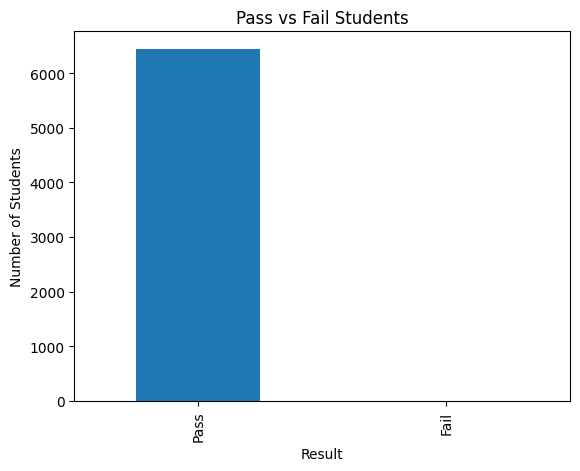

In [9]:
# Create Result column
df["Result"] = df["Exam_Score"].apply(lambda x: "Pass" if x >= 30 else "Fail")

# Plot Pass vs Fail
df["Result"].value_counts().plot(kind="bar")

plt.title("Pass vs Fail Students")
plt.xlabel("Result")
plt.ylabel("Number of Students")

plt.show()

In [11]:
print(df["Exam_Score"].min())

print(df["Result"].value_counts())

24
Result
Pass    6441
Fail       2
Name: count, dtype: int64
